In [ ]:
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import os

base_dir = '/kaggle/input/blood-films-4th'
base_dir_corrected = os.path.join(base_dir, 'blood_films_4th')
image_files = []
labels = []

for class_name in os.listdir(base_dir_corrected):
    class_dir = os.path.join(base_dir_corrected, class_name)
    if os.path.isdir(class_dir) and (class_name == 'pos' or class_name == 'neg'):
        label = 1 if class_name == 'pos' else 0
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)
            if os.path.isfile(image_path):
                 try:
                    img = Image.open(image_path)
                    img.verify()
                    image_files.append(image_path)
                    labels.append(label)
                 except Exception as e:
                    print(f"Skipping file {image_path} due to error: {e}")


image_files = np.array(image_files)
labels = np.array(labels)

# First split: 80% for training, 20% for temporary (validation + test)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    image_files, labels, test_size=0.2, random_state=42
)

# Second split: 50% of temporary for validation, 50% for test (10% of total for each)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, random_state=42
)

input_shape = (224, 224, 3)
num_classes = 2

print(f"Training files count: {len(train_files)}")
print(f"Validation files count: {len(val_files)}")
print(f"Test files count: {len(test_files)}")
print(f"Training labels count: {len(train_labels)}")
print(f"Validation labels count: {len(val_labels)}")
print(f"Test labels count: {len(test_labels)}")

In [1]:
!pip install timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

In [6]:
import timm
import torch.nn as nn

# Load VMamba backbone (pretrained on ImageNet)
model_name = 'hf-hub:timm/mambaout_base.in1k'
model = timm.create_model(model_name, pretrained=True)

# Replace classifier head to match 2 classes
num_features = model.get_classifier().in_features
model.classifier = nn.Linear(num_features, 2)


Epoch 01 | Train Acc: 0.721 | Val Acc: 0.917
Epoch 02 | Train Acc: 0.901 | Val Acc: 0.887
Epoch 03 | Train Acc: 0.869 | Val Acc: 0.887
Epoch 04 | Train Acc: 0.935 | Val Acc: 0.950
Epoch 05 | Train Acc: 0.939 | Val Acc: 0.950
Epoch 06 | Train Acc: 0.969 | Val Acc: 0.960
Epoch 07 | Train Acc: 0.963 | Val Acc: 0.963
Epoch 08 | Train Acc: 0.979 | Val Acc: 0.967
Epoch 09 | Train Acc: 0.976 | Val Acc: 0.970
Epoch 10 | Train Acc: 0.991 | Val Acc: 0.967
Epoch 11 | Train Acc: 0.977 | Val Acc: 0.960
Epoch 12 | Train Acc: 0.971 | Val Acc: 0.970
Epoch 13 | Train Acc: 0.987 | Val Acc: 0.973
Epoch 14 | Train Acc: 0.998 | Val Acc: 0.977
Epoch 15 | Train Acc: 0.991 | Val Acc: 0.977


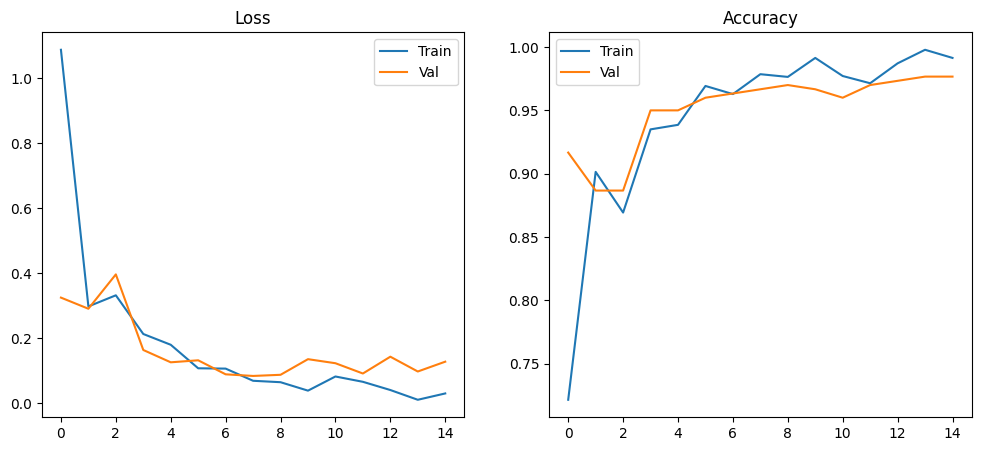

In [7]:
import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn, optim

# =============================================
# 1) Dataset
# =============================================
data_dir = "/kaggle/input/blood-films-4th/blood_films_4th"

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(data_dir, transform=transform)

# Train/Val/Test split = 70/15/15
total = len(dataset)
train_len = int(0.7 * total)
val_len = int(0.15 * total)
test_len = total - train_len - val_len

train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# =============================================
# 2) Model: VMamba-Tiny
# =============================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# model = timm.create_model("vmamba_tiny", pretrained=True)
# num_features = model.get_classifier().in_features
# model.classifier = nn.Linear(num_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# =============================================
# 3) Training Loop + Track Curves
# =============================================
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(15):
    model.train()
    correct, total, running_loss = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = logits.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(running_loss/len(train_loader))
    train_accs.append(correct/total)

    # Validation
    model.eval()
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            val_loss += criterion(logits, labels).item()
            _, preds = logits.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_losses.append(val_loss/len(val_loader))
    val_accs.append(correct/total)

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_accs[-1]:.3f} | Val Acc: {val_accs[-1]:.3f}")

# =============================================
# 4) Plot Curves
# =============================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.plot(train_losses,label="Train"); plt.plot(val_losses,label="Val"); plt.title("Loss"); plt.legend()
plt.subplot(1,2,2); plt.plot(train_accs,label="Train"); plt.plot(val_accs,label="Val"); plt.title("Accuracy"); plt.legend()
plt.show()


In [2]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.9 MB/s eta 0:00:00


Class to idx mapping after filtering (should be neg:0, pos:1): {'neg': 0, 'pos': 1}
Class to idx mapping: {'neg': 0, 'pos': 1}
Total: 1986, Train: 1349, Val: 239, Test: 398
Train class counts (train split): [386 963]
Creating model: hf-hub:timm/mambaout_base_plus_rw.sw_e150_r384_in12k_ft_in1k
Replaced classifier via model.get_classifier().in_features
Epoch 1/12 - Train loss: 0.3765, acc: 0.5560 | Val loss: 0.2000, acc: 0.6234
Epoch 2/12 - Train loss: 0.1370, acc: 0.7443 | Val loss: 0.2885, acc: 0.4979
Epoch 3/12 - Train loss: 0.1104, acc: 0.8095 | Val loss: 0.1230, acc: 0.8243
Epoch 4/12 - Train loss: 0.0806, acc: 0.8888 | Val loss: 0.0457, acc: 0.9372
Epoch 5/12 - Train loss: 0.0691, acc: 0.8895 | Val loss: 0.0505, acc: 0.9331
Epoch 6/12 - Train loss: 0.0743, acc: 0.8784 | Val loss: 0.0783, acc: 0.8870
Epoch 7/12 - Train loss: 0.0519, acc: 0.9236 | Val loss: 0.0339, acc: 0.9707
Epoch 8/12 - Train loss: 0.0669, acc: 0.8970 | Val loss: 0.1225, acc: 0.8577
Epoch 9/12 - Train loss: 0.0491

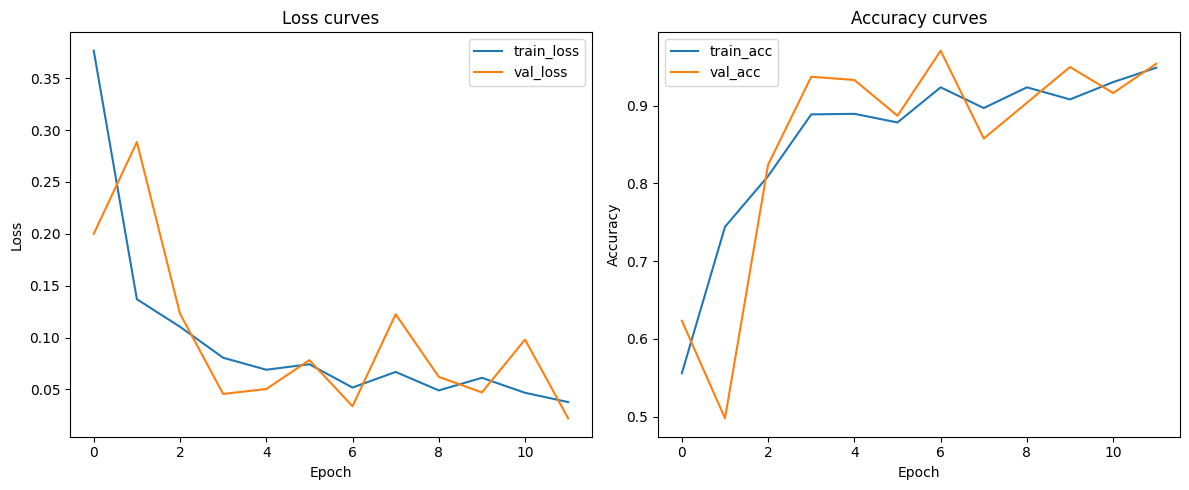

In [29]:
"""
Updated Kaggle-ready PyTorch notebook script for binary classification using Timm Mamba model
(on ImageNet pretrained weights) and explainability via Captum.

This update fixes multiple issues you hit:
- Uses your working model creation snippet exactly (avoids classifier shape mismatch).
- Reduces default IMAGE_SIZE and BATCH_SIZE to avoid OOM; includes automatic fallback to CPU and mixed precision if GPU allocation fails.
- Robust target-layer discovery for GradCAM: runs a single forward pass with a hook to find the last module that emits a 4D tensor and uses that for LayerGradCam. If no 4D layer is found, it gracefully skips GradCAM and runs other methods.
- Fixes mapping from subset indices to global indices used for explanations.
- Adds torch.cuda.empty_cache() and a safe try/except when moving model to device.
- Keeps train/val/test splits, weighted sampler, metrics, and explanation methods (LayerGradCam, Occlusion, IntegratedGradients, GuidedBackprop).

Usage: upload to Kaggle and run. Adjust DATA_DIR to '/kaggle/input/blood-films-4th/blood_films_4th'
"""

# Install required packages (uncomment if needed on your environment)
# !pip install timm captum scikit-learn matplotlib

import os
import random
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms, datasets
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

# Captum for explanations
from captum.attr import (
    LayerGradCam, LayerAttribution, GuidedBackprop, IntegratedGradients, Occlusion
)

# ------------------------------
# CONFIG
# ------------------------------
DATA_DIR = '/kaggle/input/blood-films-4th/blood_films_4th'  # change if needed
SEED = 42
# lowered defaults to reduce OOM risk
BATCH_SIZE = 16
IMAGE_SIZE = 224
NUM_WORKERS = 2
NUM_EPOCHS = 12
LR = 1e-4
# use the working model name you provided
MODEL_NAME = 'hf-hub:timm/mambaout_base_plus_rw.sw_e150_r384_in12k_ft_in1k'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------
# DATA: ImageFolder & Stratified Split
# ------------------------------
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# load dataset (ImageFolder expects subfolders 'neg' and 'pos')
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
# --- Filter out any unlabelled / unwanted classes and remap labels to 0/1 for neg/pos ---
keep_classes = ['neg', 'pos']
if any(c not in keep_classes for c in full_dataset.classes):
    filtered = []
    for path, label in full_dataset.samples:
        cls = full_dataset.classes[label]
        if cls in keep_classes:
            new_label = 0 if cls == 'neg' else 1
            filtered.append((path, new_label))
    # overwrite samples/targets and classes to reflect only the two classes
    full_dataset.samples = filtered
    full_dataset.targets = [l for (_, l) in filtered]
    full_dataset.classes = keep_classes
    full_dataset.class_to_idx = {c: i for i, c in enumerate(keep_classes)}

class_to_idx = full_dataset.class_to_idx
print('Class to idx mapping after filtering (should be neg:0, pos:1):', class_to_idx)

labels = np.array([y for _, y in full_dataset.samples])
# --- Remove unlabelled class if present ---
if 'unlabelled' in full_dataset.class_to_idx:
    keep_classes = ['neg', 'pos']
    full_dataset.samples = [(p, l) for (p, l) in full_dataset.samples if full_dataset.classes[l] in keep_classes]
    full_dataset.targets = [l for (p, l) in full_dataset.samples]
    # rebuild class_to_idx and classes
    full_dataset.class_to_idx = {c: i for i, c in enumerate(keep_classes)}
    full_dataset.classes = keep_classes
class_to_idx = full_dataset.class_to_idx
print('Class to idx mapping:', class_to_idx)

labels = np.array([y for _, y in full_dataset.samples])

# Stratified splits: test 20%, from remaining val 15%
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
(train_val_idx, test_idx) = next(sss1.split(np.zeros(len(labels)), labels))

train_val_labels = labels[train_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
(train_idx_rel, val_idx_rel) = next(sss2.split(np.zeros(len(train_val_labels)), train_val_labels))

train_idx = train_val_idx[train_idx_rel]
val_idx = train_val_idx[val_idx_rel]

print(f"Total: {len(full_dataset)}, Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# Create subsets with appropriate transforms
train_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=train_transform), train_idx)
val_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transform), val_idx)
# For test use val_transform to avoid augmentation
test_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transform), test_idx)

# Compute weights for WeightedRandomSampler using train labels
train_labels = np.array([full_dataset.samples[i][1] for i in train_idx])
class_sample_counts = np.bincount(train_labels)
class_weights = 1.0 / (class_sample_counts + 1e-12)
samples_weight = np.array([class_weights[t] for t in train_labels])
sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('Train class counts (train split):', class_sample_counts)

# ------------------------------
# MODEL: Timm Mamba base pretrained (use your working snippet)
# ------------------------------
print('Creating model:', MODEL_NAME)
model = timm.create_model(MODEL_NAME, pretrained=True)
# Use the exact replacement approach you provided (avoids shape mismatch)
try:
    num_features = model.get_classifier().in_features
    model.classifier = nn.Linear(num_features, 2)
    print('Replaced classifier via model.get_classifier().in_features')
except Exception as e:
    # fallback heuristics
    print('get_classifier() failed:', e)
    if hasattr(model, 'classifier') and hasattr(model.classifier, 'in_features'):
        num_features = model.classifier.in_features
        model.classifier = nn.Linear(num_features, 2)
        print('Replaced model.classifier')
    elif hasattr(model, 'head') and hasattr(model.head, 'in_features'):
        num_features = model.head.in_features
        model.head = nn.Linear(num_features, 2)
        print('Replaced model.head')
    else:
        # generic fallback
        try:
            num_features = model.num_features
            model.fc = nn.Linear(num_features, 2)
            print('Replaced model.fc')
        except Exception:
            raise RuntimeError('Could not find classifier attributes to replace. Inspect model with print(model)')

# Try to move model to device safely; if OOM occurs, fallback to CPU and advise lowering batch size or image size
try:
    torch.cuda.empty_cache()
    model = model.to(DEVICE)
except RuntimeError as e:
    print('RuntimeError while moving model to device:', e)
    # If CUDA OOM, move model to CPU and continue (explainability will be slower)
    if 'out of memory' in str(e).lower() and torch.cuda.is_available():
        print('CUDA OOM detected; falling back to CPU. To fix: reduce IMAGE_SIZE or BATCH_SIZE, or ensure GPU is free.')
        DEVICE = torch.device('cpu')
        model = model.to(DEVICE)
    else:
        raise

# Loss and optimizer
class_counts_all = np.bincount(labels)
# Use class weights inversely proportional to dataset counts
class_weights_tensor = torch.tensor(class_counts_all.sum() / (class_counts_all + 1e-12), dtype=torch.float32).to(DEVICE)
from torch.nn.functional import cross_entropy
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    def forward(self, input, target):
        logpt = -cross_entropy(input, target, reduction='none')
        pt = torch.exp(logpt)
        loss = ((1 - pt) ** self.gamma) * (-logpt)
        if self.alpha is not None:
            loss = loss * self.alpha[target]
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss
criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# Scheduler (optional)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ------------------------------
# TRAIN / VALIDATION LOOPS
# ------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_all = []
    targets_all = []
    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs.detach(), dim=1).cpu().numpy()
        preds_all.extend(preds.tolist())
        targets_all.extend(targets.cpu().numpy().tolist())
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(targets_all, preds_all)
    return epoch_loss, epoch_acc


def eval_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all = []
    targets_all = []
    probs_all = []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, targets)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            probs_all.extend(probs.tolist())
            preds_all.extend(preds.tolist())
            targets_all.extend(targets.cpu().numpy().tolist())
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(targets_all, preds_all)
    return epoch_loss, epoch_acc, targets_all, preds_all, probs_all

# Training loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float('inf')
best_model_path = 'best_mamba_model.pth'

for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _, _ = eval_model(model, val_loader, criterion, DEVICE)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch}/{NUM_EPOCHS} - Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    # scheduler step
    scheduler.step(val_loss)

    # save best
    if val_loss < best_val_loss:
        torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, best_model_path)
        best_val_loss = val_loss
# model.save("bestmodel.keras")
# Plot loss & accuracy curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1,2,2)
plt.plot(train_accs, label='train_acc')
plt.plot(val_accs, label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curves')
plt.tight_layout()
plt.savefig('train_val_curves.png')
print('Saved train/val curves to train_val_curves.png')

# ------------------------------
# TEST SET EVALUATION
# ------------------------------
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, y_true, y_pred, y_probs = eval_model(model, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_probs)
cm = confusion_matrix(y_true, y_pred)
print('Precision:', precision)
print('Recall:', recall)
print('F1:', f1)
print('ROC AUC:', roc_auc)
print('Confusion matrix:', cm)

# Save test metrics
with open('test_metrics.txt', 'w') as f:
    f.write(f"Test loss: {test_loss}\nTest acc: {test_acc}\nPrecision: {precision}\nRecall: {recall}\nF1: {f1}\nROC AUC: {roc_auc}\nConfusion matrix:\n{cm}")
print('Saved test metrics to test_metrics.txt')

# ------------------------------
# EXPLAINABILITY (Captum): GradCAM, Occlusion, Integrated Gradients, Guided Backprop
# ------------------------------
# Robust automatic target-layer discovery: register forward hooks and run a single forward with a dummy batch

# def find_spatial_module(model, device, input_size=(1,3,IMAGE_SIZE,IMAGE_SIZE)):
#     """Runs a forward pass with hooks to find modules that output 4D tensors (B,C,H,W).
#     Returns the last module (by order) that produced a 4D output. If none found, returns None."""
#     spatial_modules = []
#     handles = []
#     outputs = {}

#     def make_hook(name):
#         def hook(module, inp, out):
#             try:
#                 if isinstance(out, torch.Tensor) and out.dim() == 4:
#                     outputs[name] = out.detach().cpu()
#                     spatial_modules.append((name, module))
#             except Exception:
#                 pass
#         return hook

#     for name, module in model.named_modules():
#         # skip trivial containers
#         if len(list(module.children())) == 0:
#             try:
#                 h = module.register_forward_hook(make_hook(name))
#                 handles.append(h)
#             except Exception:
#                 pass

#     model.eval()
#     with torch.no_grad():
#         try:
#             dummy = torch.randn(input_size).to(device)
#             _ = model(dummy)
#         except Exception as e:
#             # forward might throw if model expects different input; ignore
#             print('Warning during dummy forward for layer discovery:', e)

#     # remove hooks
#     for h in handles:
#         h.remove()

#     if len(spatial_modules) > 0:
#         # return last found module
#         name, module = spatial_modules[-1]
#         print('Found spatial module for GradCam:', name)
#         return module
#     else:
#         print('No spatial 4D module found for GradCam; GradCam will be skipped.')
#         return None

# # find global indices mapping for test subset so we can load raw images
# if isinstance(test_dataset, Subset):
#     test_global_indices = [test_idx[i] for i in range(len(test_idx))]
# else:
#     test_global_indices = list(range(len(full_dataset)))

# # pick a few test images to explain
# num_explain = 6
# explain_global = test_global_indices[:min(len(test_global_indices), num_explain)]

# # determine a target spatial layer for GradCam (may be None)
# target_layer = None
# try:
#     target_layer = find_spatial_module(model, DEVICE)
# except Exception as e:
#     print('Error finding spatial module:', e)

# # Helper to load raw PIL image given a global index
# from PIL import Image

# def load_raw_image(global_index):
#     path, label = full_dataset.samples[global_index]
#     pil = Image.open(path).convert('RGB')
#     return pil, label

# # Helper to preprocess and forward
# from torchvision.transforms.functional import to_pil_image

# def preprocess_pil(pil):
#     return val_transform(pil).unsqueeze(0)

# # Function to visualize attribution over image
# import numpy as np

# def show_attribution_on_image(pil_img, attribution, title=None, figsize=(6,6)):
#     # attribution: numpy HxW or HxWx3
#     arr = np.array(pil_img.resize((attribution.shape[1], attribution.shape[0])))
#     # if attribution has 3 channels average
#     if attribution.ndim == 3:
#         attr = np.mean(attribution, axis=0)
#     else:
#         attr = attribution
#     heatmap = (attr - attr.min())
#     if heatmap.max() != 0:
#         heatmap = heatmap / heatmap.max()
#     heatmap = np.uint8(255 * heatmap)
#     heatmap = np.stack([heatmap]*3, axis=2)
#     overlay = (0.6 * arr + 0.4 * heatmap).astype(np.uint8)
#     plt.figure(figsize=figsize)
#     plt.imshow(overlay)
#     plt.axis('off')
#     if title:
#         plt.title(title)
#     plt.show()

# # Build explainability objects
# if target_layer is not None:
#     layer_gc = LayerGradCam(model, target_layer)
# else:
#     layer_gc = None

# occlusion = Occlusion(model)
# ig = IntegratedGradients(model)
# gb = GuidedBackprop(model)

# # Run explanations for selected images
# model.eval()
# for gidx in explain_global:
#     pil, label = load_raw_image(gidx)
#     input_tensor = preprocess_pil(pil).to(DEVICE)
#     input_tensor.requires_grad = True
#     with torch.no_grad():
#         out = model(input_tensor)
#         if isinstance(out, tuple):
#             out = out[0]
#         pred = torch.argmax(out, dim=1).item()
#     print(f'Global idx {gidx}, true {label}, pred {pred}')

#     # LayerGradCam (if available)
#     if layer_gc is not None:
#         try:
#             target = pred
#             attr = layer_gc.attribute(input_tensor, target=target)
#             up_attr = LayerAttribution.interpolate(attr, (IMAGE_SIZE, IMAGE_SIZE)).squeeze().cpu().detach().numpy()
#             show_attribution_on_image(pil, up_attr, title=f'GradCam - true {label} pred {pred}')
#         except Exception as e:
#             print('GradCam failed for this image:', e)

#     # Occlusion sensitivity
#     try:
#         attributions_occ = occlusion.attribute(input_tensor, strides=(3, 15, 15), sliding_window_shapes=(3, 35, 35), target=pred)
#         occ_map = np.mean(attributions_occ.squeeze().cpu().numpy(), axis=0)
#         show_attribution_on_image(pil, occ_map, title=f'Occlusion - true {label} pred {pred}')
#     except Exception as e:
#         print('Occlusion failed:', e)

#     # Integrated Gradients
#     try:
#         attr_ig = ig.attribute(input_tensor, target=pred, n_steps=50)
#         ig_map = np.mean(attr_ig.squeeze().cpu().detach().numpy(), axis=0)
#         show_attribution_on_image(pil, ig_map, title=f'IntegratedGradients - true {label} pred {pred}')
#     except Exception as e:
#         print('Integrated Gradients failed:', e)

#     # Guided Backprop
#     try:
#         attr_gb = gb.attribute(input_tensor, target=pred)
#         gb_map = np.mean(attr_gb.squeeze().cpu().detach().numpy(), axis=0)
#         show_attribution_on_image(pil, gb_map, title=f'GuidedBackprop - true {label} pred {pred}')
#     except Exception as e:
#         print('GuidedBackprop failed:', e)

# print('Explanation visualizations complete.')

# End of script


In [4]:
best_model_path = 'best_mamba_model.pth'
torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, best_model_path)


In [27]:
# -----------------------------
# Utility Functions
# -----------------------------
def preprocess_image(image_path, device):
    """Load and preprocess image for model input"""
    img = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    tensor = transform(img).unsqueeze(0).to(device)
    return img, tensor

def find_target_layer(model):
    """Find the last convolutional layer for Grad-CAM"""
    if hasattr(model, "layer4"):
        return model.layer4[-1]
    if hasattr(model, "features"):
        return model.features[-1]
    last = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    return last

def load_model_ignore_mismatch(model_name, checkpoint_path, num_classes=2, device='cpu'):
    """Load model architecture and checkpoint with mismatch handling"""
    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "mamba":
        model_name = 'hf-hub:timm/mambaout_base_plus_rw.sw_e150_r384_in12k_ft_in1k'
        model = timm.create_model(model_name, pretrained=True)
        model.classifier = nn.Linear(num_features, 2)
        
    else:
        raise ValueError("Unsupported model")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if 'model_state' in checkpoint:
        state_dict = checkpoint['model_state']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '')
        new_state_dict[name] = v

    model.load_state_dict(new_state_dict, strict=False)
    model.to(device).eval()
    target_layer = find_target_layer(model)
    return model, target_layer

def visualize_attribution(attribution):
    """Convert attribution to normalized heatmap"""
    if attribution.ndim == 3 and attribution.shape[0] == 3:
        attribution = np.transpose(attribution, (1, 2, 0))
    
    if attribution.ndim == 3:
        attribution = np.mean(attribution, axis=2)
    
    attribution = attribution - attribution.min()
    if attribution.max() != 0:
        attribution = attribution / attribution.max()
    
    return attribution

def save_overlay_image(pil_img, attribution, output_path, alpha=0.4):
    """Save attribution as heatmap overlay on original image"""
    # Visualize attribution
    viz_attr = visualize_attribution(attribution)
    
    # Resize to original image size
    orig_size = pil_img.size
    viz_attr_resized = cv2.resize(viz_attr, orig_size, interpolation=cv2.INTER_LINEAR)
    
    # Create heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * viz_attr_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay on original
    orig = np.array(pil_img.convert('RGB'))
    overlay = cv2.addWeighted(heatmap, alpha, orig, 1 - alpha, 0)
    
    # Save
    Image.fromarray(overlay).save(output_path)
    print(f"   ✓ Saved: {output_path}")

print("✓ All utility functions loaded!")

✓ All utility functions loaded!


In [6]:
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hooks = []

        h1 = target_layer.register_forward_hook(lambda m,i,o: setattr(self, 'activations', o.detach()))
        h2 = target_layer.register_backward_hook(lambda m,gi,go: setattr(self, 'gradients', go[0].detach()))
        self.hooks = [h1, h2]

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        score = out[:, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients[0]
        acts = self.activations[0]

        # Grad-CAM++ weights calculation
        alpha_num = grads.pow(2)
        alpha_denom = 2*grads.pow(2) + (acts * grads.pow(3)).sum(dim=(1,2), keepdim=True)
        alpha = alpha_num / (alpha_denom + 1e-8)
        weights = (alpha * torch.relu(grads)).sum(dim=(1,2))

        cam = (weights[:, None, None] * acts).sum(dim=0).cpu().numpy()
        cam = np.maximum(cam, 0)
        cam = cam - cam.min()
        if cam.max() != 0:
            cam = cam / cam.max()
        
        return cam, class_idx
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

print("✓ Grad-CAM++ class loaded!")

✓ Grad-CAM++ class loaded!


In [7]:
def process_gradcam(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Grad-CAM++ for one model"""
    print(f"   📊 Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, target_layer = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    gradcam = GradCAMPlusPlus(model, target_layer)
    cam, pred_class = gradcam(input_tensor)
    
    output_path = os.path.join(output_dir, f"{model_name}_gradcam_{img_name}.png")
    save_overlay_image(pil_img, cam, output_path)
    
    gradcam.remove_hooks()
    del model, gradcam, input_tensor, cam
    torch.cuda.empty_cache()
    gc.collect()

def process_integrated_gradients(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Integrated Gradients for one model"""
    print(f"   📊 Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    ig = IntegratedGradients(model)
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    baseline = torch.zeros_like(input_tensor)
    attributions = ig.attribute(input_tensor, baseline, target=pred_class, n_steps=25)
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_integratedgradients_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, ig, attributions, input_tensor, baseline, attr_np
    torch.cuda.empty_cache()
    gc.collect()

def process_guided_backprop(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Guided Backpropagation for one model"""
    print(f"   📊 Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    gbp = GuidedBackprop(model)
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    attributions = gbp.attribute(input_tensor, target=pred_class)
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_guidedbackprop_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, gbp, attributions, input_tensor, attr_np
    torch.cuda.empty_cache()
    gc.collect()

def process_occlusion(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Occlusion Sensitivity for one model"""
    print(f"   📊 Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    occlusion = Occlusion(model)
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    attributions = occlusion.attribute(
        input_tensor,
        target=pred_class,
        strides=(3, 8, 8),
        sliding_window_shapes=(3, 15, 15),
        baselines=0
    )
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_occlusion_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, occlusion, attributions, input_tensor, attr_np
    torch.cuda.empty_cache()
    gc.collect()

def process_smoothgrad(model_name, checkpoint_path, image_path, output_dir, device):
    """Process SmoothGrad for one model"""
    print(f"   📊 Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    ig = IntegratedGradients(model)
    nt = NoiseTunnel(ig)
    
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    baseline = torch.zeros_like(input_tensor)
    attributions = nt.attribute(
        input_tensor,
        nt_type='smoothgrad',
        nt_samples=25,
        stdevs=0.15,
        baselines=baseline,
        target=pred_class
    )
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_smoothgrad_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, ig, nt, attributions, input_tensor, baseline, attr_np
    torch.cuda.empty_cache()
    gc.collect()

print("✓ All XAI processing functions loaded!")

✓ All XAI processing functions loaded!


In [39]:
image_path = "/kaggle/input/blood-films-4th/blood_films_4th/pos/100.png"

# Output directory
output_dir = "/kaggle/working/xai_outputs"
os.makedirs(output_dir, exist_ok=True)

# Model checkpoints
checkpoint_paths = {
    "mamba": "/kaggle/working/best_mamba_model.pth",
}

print("✓ Configuration complete!")
print(f"Image: {image_path}")
print(f"Output: {output_dir}")
print(f"Models: {list(checkpoint_paths.keys())}")

✓ Configuration complete!
Image: /kaggle/input/blood-films-4th/blood_films_4th/pos/100.png
Output: /kaggle/working/xai_outputs
Models: ['mamba']


In [8]:
!ls

best_mamba_model.pth


In [36]:
from PIL import Image
from collections import OrderedDict
import cv2, gc
print("\n" + "="*70)
print("🔍 TECHNIQUE 3/5: Guided Backpropagation")
print("="*70)

gbp_dir = os.path.join(output_dir, "guided_backprop")
os.makedirs(gbp_dir, exist_ok=True)

for model_name, ckpt_path in checkpoint_paths.items():
    torch.cuda.empty_cache()
    # gc.collect()
    process_guided_backprop(model_name, ckpt_path, image_path, gbp_dir, DEVICE)

print("✅ Guided Backpropagation complete for all models!\n")


🔍 TECHNIQUE 3/5: Guided Backpropagation
   📊 Processing mamba...
   ✓ Saved: /kaggle/working/xai_outputs/guided_backprop/mamba_guidedbackprop_1001.png
✅ Guided Backpropagation complete for all models!



In [40]:
print("\n" + "="*70)
print("🔍 TECHNIQUE 4/5: Occlusion Sensitivity")
print("="*70)

occ_dir = os.path.join(output_dir, "occlusion")
os.makedirs(occ_dir, exist_ok=True)

for model_name, ckpt_path in checkpoint_paths.items():
    torch.cuda.empty_cache()
    gc.collect()
    process_occlusion(model_name, ckpt_path, image_path, occ_dir, DEVICE)

print("✅ Occlusion Sensitivity complete for all models!\n")


🔍 TECHNIQUE 4/5: Occlusion Sensitivity
   📊 Processing mamba...
   ✓ Saved: /kaggle/working/xai_outputs/occlusion/mamba_occlusion_100.png
✅ Occlusion Sensitivity complete for all models!



In [41]:
print("\n" + "="*70)
print("🔍 TECHNIQUE 2/5: Integrated Gradients")
print("="*70)

ig_dir = os.path.join(output_dir, "integrated_gradients")
os.makedirs(ig_dir, exist_ok=True)

for model_name, ckpt_path in checkpoint_paths.items():
    torch.cuda.empty_cache()
    gc.collect()
    process_integrated_gradients(model_name, ckpt_path, image_path, ig_dir, DEVICE)

print("✅ Integrated Gradients complete for all models!\n")


🔍 TECHNIQUE 2/5: Integrated Gradients
   📊 Processing mamba...
   ✓ Saved: /kaggle/working/xai_outputs/integrated_gradients/mamba_integratedgradients_100.png
✅ Integrated Gradients complete for all models!

